In [ ]:
!pip install pyroomacoustics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.1/35.1 MB 46.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.3-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.3-py3-none-any.whl (313 kB)
  Created wheel for pyroomacoustics: filename=pyroomacoustics-0.10.0-cp312-cp312-linux_x86_64.whl size=48190063 sha256=43c2806fb6f32d22e9620bb0a52aa95e2907b2598a0fe686289c8b3f9052e2fd
  Stored in directory: /root/.cache/pip/wheels/d8/7b/93/7612ac296836608f02f6ea170644cc2924344442276040d928
Successfully built pyroomacoustics


Moving Source Generator

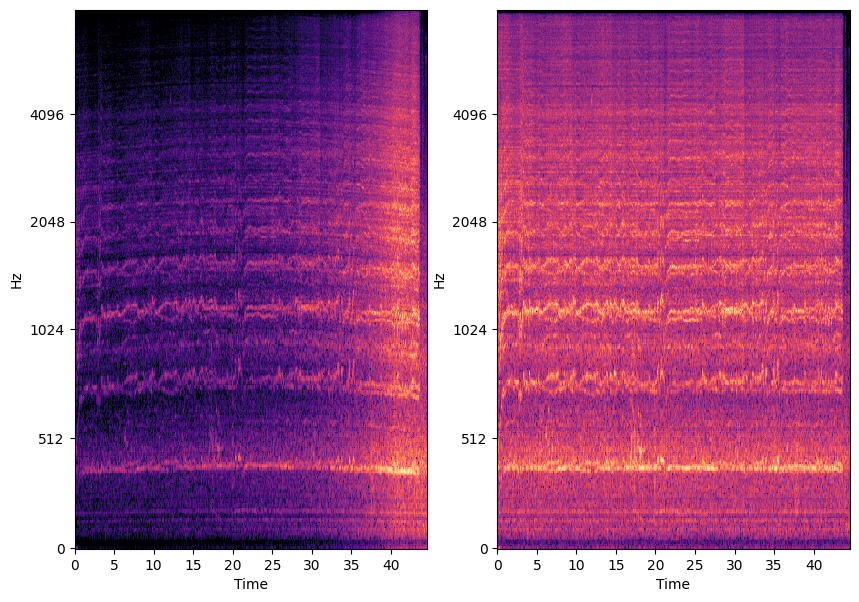

In [ ]:
import numpy as np
import librosa
import soundfile as sf
signal, fs = librosa.load('/content/20260209_165531_ch3.wav', sr=16000)
c = 343.0
start_pos = np.array([1000.0, 0.0, 0.0])
end_pos   = np.array([0.0,    0.0, 0.0])
N = len(signal)
t_norm = np.linspace(0, 1, N)

# trajectory(ACCELERATION) eqn
scale = 9 * t_norm**2 - 6 * t_norm**3
a = scale
a_norm = (a - np.min(a)) / (np.max(a) - np.min(a))
scale = a_norm
trajectory = start_pos[None, :] * (1 - scale[:, None]) + end_pos[None, :] * scale[:, None]  # (N, 3)

distances = np.linalg.norm(trajectory, axis=1)  # (N,)
distances = np.maximum(distances, 0.01)  # avoid divide-by-zero
# d(distance)/dt: positive = moving away, negative = moving toward
d_dist = np.gradient(distances, 1.0 / fs)  # m/s, radial velocity

#f_observed = f_source * c / (c + v_radial)
doppler_factor = c / (c + d_dist)
# At each output sample n, we read from input sample warp_index[n]
warp_index = np.cumsum(doppler_factor)
warp_index = warp_index / warp_index[-1] * (N - 1)  # normalize to input length
warp_index = np.clip(warp_index, 0, N - 1)

# Resample signal using the warped indices (linear interpolation)
i0 = np.floor(warp_index).astype(int)
i1 = np.minimum(i0 + 1, N - 1)
frac = warp_index - i0
doppler_signal = signal[i0] * (1 - frac) + signal[i1] * frac

#Distance attenuation
ref_distance = distances[0]
attenuation = ref_distance / distances
attenuation = np.minimum(attenuation, 50.0)  #max gain to avoid blowup

output = doppler_signal * attenuation
output = output / np.max(np.abs(output))
figs, ax = plt.subplots(ncols=2,figsize=(10,7))
S_t = librosa.feature.melspectrogram(y=output, sr=fs, n_mels=512,fmax=8000)
librosa.display.specshow(librosa.power_to_db(S_t, ref=np.max),x_axis='time', y_axis='mel', fmax=8000, ax=ax[0])
ss = librosa.feature.melspectrogram(y=signal, sr=fs, n_mels=512,fmax=8000)
librosa.display.specshow(librosa.power_to_db(ss, ref=np.max),x_axis='time', y_axis='mel', fmax=8000, ax = ax[1])
#sf.write("moving_source_output_drone.wav", output, fs)